# Greeks & Dynamic Delta-Hedging

**Objectif** : calculer les Greeks (Delta, Gamma, Vega, Theta, Rho) d'une option européenne,
puis simuler une stratégie de **delta-hedging dynamique** sur des trajectoires Monte Carlo,
afin de quantifier le **P&L résiduel de couverture** en fonction de la fréquence de rebalancement.

Ce projet fait le lien entre :
- la théorie du modèle binomial / réplication (Shreve, *Stochastic Calculus for Finance I*, Ch.1)
- une implémentation numérique réaliste en temps continu (Black-Scholes + Monte Carlo)
- une perspective **gestion des risques / validation de modèle** : que se passe-t-il si on
  rebalance trop rarement, ou si la vol utilisée pour couvrir est mal calibrée ?

**Plan**
1. Pricing Black-Scholes et Greeks analytiques
2. Greeks par différences finies (vérification / approche modèle-agnostique)
3. Simulation de trajectoires GBM
4. Delta-hedging dynamique : P&L de couverture vs fréquence de rebalancement
5. Impact d'une vol de hedge mal calibrée
6. Conclusion + Q&A entretien


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)
plt.rcParams['figure.figsize'] = (9, 5)


## 1. Pricing Black-Scholes et Greeks analytiques

In [2]:
def bs_price(S, K, T, r, sigma, option_type='call'):
    """Prix Black-Scholes d'une option européenne."""
    if T <= 0:
        return max(S - K, 0.0) if option_type == 'call' else max(K - S, 0.0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == 'call':
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)


def bs_greeks(S, K, T, r, sigma, option_type='call'):
    """Greeks analytiques Black-Scholes."""
    if T <= 0:
        return dict(delta=np.nan, gamma=np.nan, vega=np.nan, theta=np.nan, rho=np.nan)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    pdf_d1 = norm.pdf(d1)

    if option_type == 'call':
        delta = norm.cdf(d1)
        theta = (-S * pdf_d1 * sigma / (2 * np.sqrt(T))
                 - r * K * np.exp(-r * T) * norm.cdf(d2))
        rho = K * T * np.exp(-r * T) * norm.cdf(d2)
    else:
        delta = norm.cdf(d1) - 1
        theta = (-S * pdf_d1 * sigma / (2 * np.sqrt(T))
                 + r * K * np.exp(-r * T) * norm.cdf(-d2))
        rho = -K * T * np.exp(-r * T) * norm.cdf(-d2)

    gamma = pdf_d1 / (S * sigma * np.sqrt(T))
    vega = S * pdf_d1 * np.sqrt(T)

    return dict(delta=delta, gamma=gamma, vega=vega / 100, theta=theta / 365, rho=rho / 100)


# Exemple
S0, K, T, r, sigma = 100, 100, 1.0, 0.03, 0.20
price = bs_price(S0, K, T, r, sigma, 'call')
greeks = bs_greeks(S0, K, T, r, sigma, 'call')
print(f"Prix call ATM : {price:.4f}")
for g, v in greeks.items():
    print(f"  {g:>6s} : {v:.5f}")


Prix call ATM : 9.4134
   delta : 0.59871
   gamma : 0.01933
    vega : 0.38667
   theta : -0.01474
     rho : 0.50457


## 2. Vérification par différences finies

Approche modèle-agnostique, réutilisable même sans formule fermée (utile pour Monte Carlo / produits exotiques).

In [3]:
def greeks_finite_diff(pricing_fn, S, K, T, r, sigma, option_type='call',
                        dS=1e-2, dSigma=1e-4, dT=1e-4, dr=1e-4):
    base = pricing_fn(S, K, T, r, sigma, option_type)

    delta = (pricing_fn(S + dS, K, T, r, sigma, option_type)
              - pricing_fn(S - dS, K, T, r, sigma, option_type)) / (2 * dS)

    gamma = (pricing_fn(S + dS, K, T, r, sigma, option_type)
              - 2 * base
              + pricing_fn(S - dS, K, T, r, sigma, option_type)) / (dS ** 2)

    vega = (pricing_fn(S, K, T, r, sigma + dSigma, option_type)
             - pricing_fn(S, K, T, r, sigma - dSigma, option_type)) / (2 * dSigma) / 100

    theta = (pricing_fn(S, K, T - dT, r, sigma, option_type) - base) / dT / 365

    rho = (pricing_fn(S, K, T, r + dr, sigma, option_type)
            - pricing_fn(S, K, T, r - dr, sigma, option_type)) / (2 * dr) / 100

    return dict(delta=delta, gamma=gamma, vega=vega, theta=theta, rho=rho)


fd_greeks = greeks_finite_diff(bs_price, S0, K, T, r, sigma, 'call')
comparison = pd.DataFrame({'Analytique': greeks, 'Diff. finies': fd_greeks})
comparison['Écart abs.'] = (comparison['Analytique'] - comparison['Diff. finies']).abs()
comparison


,Analytique,Diff. finies,Écart abs.
delta,0.598706,0.598706,7.249751e-09
gamma,0.019333,0.019333,3.502683e-10
vega,0.386668,0.386668,1.246062e-09
theta,-0.014741,-0.014741,2.836556e-07
rho,0.504572,0.504572,6.408893e-09


## 3. Simulation de trajectoires GBM (sous mesure risque-neutre)

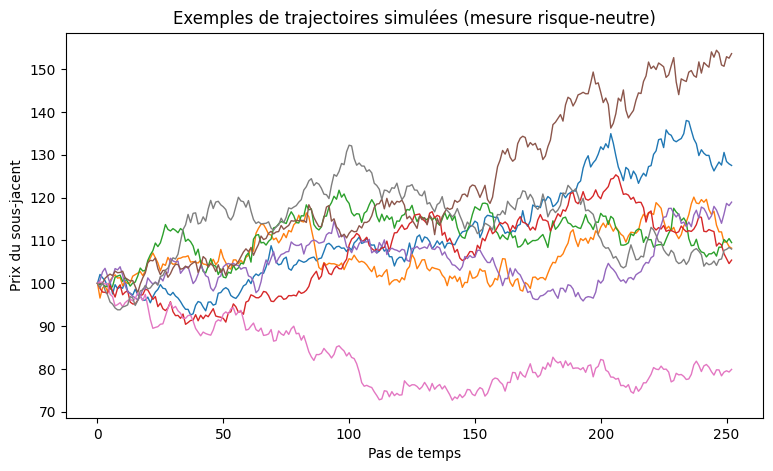

In [4]:
def simulate_gbm_paths(S0, r, sigma, T, n_steps, n_paths, seed=None):
    """Trajectoires de St sous la mesure risque-neutre (drift = r, PAS mu réel)."""
    if seed is not None:
        np.random.seed(seed)
    dt = T / n_steps
    Z = np.random.standard_normal((n_paths, n_steps))
    log_increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_paths = np.concatenate([np.zeros((n_paths, 1)), np.cumsum(log_increments, axis=1)], axis=1)
    return S0 * np.exp(log_paths)


paths = simulate_gbm_paths(S0, r, sigma, T, n_steps=252, n_paths=8, seed=1)
plt.plot(paths.T, lw=1)
plt.title("Exemples de trajectoires simulées (mesure risque-neutre)")
plt.xlabel("Pas de temps")
plt.ylabel("Prix du sous-jacent")
plt.show()


## 4. Delta-hedging dynamique

Stratégie classique de réplication : on vend un call, on détient `delta(t)` actions du sous-jacent,
on emprunte/place le solde au taux sans risque, et on **rebalance** à fréquence fixe.

Le **P&L de couverture résiduel** mesure l'écart entre la couverture théorique continue
(parfaite, comme dans le modèle binomial limite de Shreve) et la couverture discrète réalisable.


In [5]:
def delta_hedge_simulation(S0, K, T, r, sigma, n_steps, n_paths,
                            option_type='call', hedge_sigma=None, seed=None):
    """
    Simule la couverture en delta d'une position courte sur un call/put.
    hedge_sigma : vol utilisée pour CALCULER le delta de couverture (peut différer
                  de la vol réelle 'sigma' utilisée pour générer les trajectoires --
                  permet de tester un hedge mal calibré, cf. section 5).
    Retourne le P&L final de la position couverte, pour chaque trajectoire.
    """
    if hedge_sigma is None:
        hedge_sigma = sigma

    paths = simulate_gbm_paths(S0, r, sigma, T, n_steps, n_paths, seed=seed)
    dt = T / n_steps

    option_premium = bs_price(S0, K, T, r, hedge_sigma, option_type)

    cash = option_premium  # on reçoit la prime en vendant l'option
    shares = np.zeros(n_paths)
    cash = np.full(n_paths, option_premium)

    def vectorized_delta(S, K, T, r, sigma, option_type):
        T = np.maximum(T, 1e-8)
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        return norm.cdf(d1) if option_type == 'call' else norm.cdf(d1) - 1

    for i in range(n_steps):
        t_remaining = T - i * dt
        S_t = paths[:, i]
        delta_t = vectorized_delta(S_t, K, t_remaining, r, hedge_sigma, option_type)
        d_shares = delta_t - shares
        cash -= d_shares * S_t          # achat/vente d'actions pour ajuster le delta
        cash *= np.exp(r * dt)          # capitalisation du cash au taux sans risque
        shares = delta_t

    S_T = paths[:, -1]
    payoff = np.maximum(S_T - K, 0) if option_type == 'call' else np.maximum(K - S_T, 0)
    portfolio_value = cash + shares * S_T - payoff   # on doit payer le payoff à l'échéance
    return portfolio_value  # P&L de la stratégie (idéalement proche de 0)


### P&L de couverture en fonction de la fréquence de rebalancement

On s'attend à ce que l'écart-type du P&L **diminue** quand on rebalance plus souvent (convergence vers la réplication continue parfaite).

In [6]:
n_paths = 5000
rebalance_freqs = [4, 12, 26, 52, 126, 252]  # nb de rebalancements sur 1 an
pnl_std = []
pnl_mean = []

for n_steps in rebalance_freqs:
    pnl = delta_hedge_simulation(S0, K, T, r, sigma, n_steps, n_paths, seed=2024)
    pnl_std.append(pnl.std())
    pnl_mean.append(pnl.mean())

results = pd.DataFrame({
    'Rebalancements/an': rebalance_freqs,
    'P&L moyen': pnl_mean,
    'Écart-type P&L': pnl_std
})
results


,Rebalancements/an,P&L moyen,Écart-type P&L
0,4,-0.075506,3.204144
1,12,-0.030547,1.948344
2,26,-0.003814,1.342177
3,52,-0.023484,0.950909
4,126,-0.012553,0.619795
5,252,-0.008102,0.442858


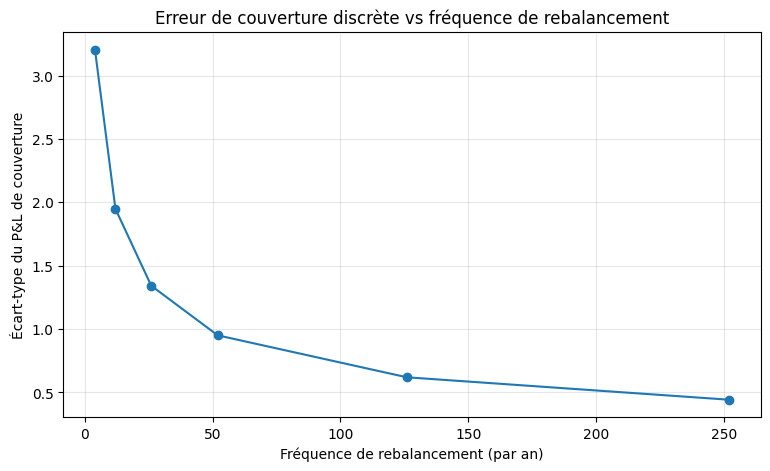

In [7]:
plt.plot(results['Rebalancements/an'], results['Écart-type P&L'], marker='o')
plt.xlabel("Fréquence de rebalancement (par an)")
plt.ylabel("Écart-type du P&L de couverture")
plt.title("Erreur de couverture discrète vs fréquence de rebalancement")
plt.grid(alpha=0.3)
plt.show()


## 5. Impact d'une vol de hedge mal calibrée

Question de validation de modèle : que se passe-t-il si le trader couvre avec une **vol
implicite erronée** (`hedge_sigma != sigma_réelle`) ? On isole l'effet d'un biais de calibration,
indépendamment de la fréquence de rebalancement.


In [8]:
real_sigma = 0.20
hedge_sigmas = np.array([0.12, 0.16, 0.20, 0.24, 0.28])
n_steps_fixed = 52  # rebalancement hebdomadaire
mean_pnls, std_pnls = [], []

for hs in hedge_sigmas:
    pnl = delta_hedge_simulation(S0, K, T, r, real_sigma, n_steps_fixed, n_paths,
                                  hedge_sigma=hs, seed=7)
    mean_pnls.append(pnl.mean())
    std_pnls.append(pnl.std())

mis_cal = pd.DataFrame({
    'Vol de hedge': hedge_sigmas,
    'Vol réelle': real_sigma,
    'P&L moyen': mean_pnls,
    'Écart-type P&L': std_pnls
})
mis_cal


,Vol de hedge,Vol réelle,P&L moyen,Écart-type P&L
0,0.12,0.2,-3.150576,1.797149
1,0.16,0.2,-1.576433,1.177009
2,0.20,0.2,0.010091,0.973553
3,0.24,0.2,1.601810,1.121385
4,0.28,0.2,3.195123,1.400432


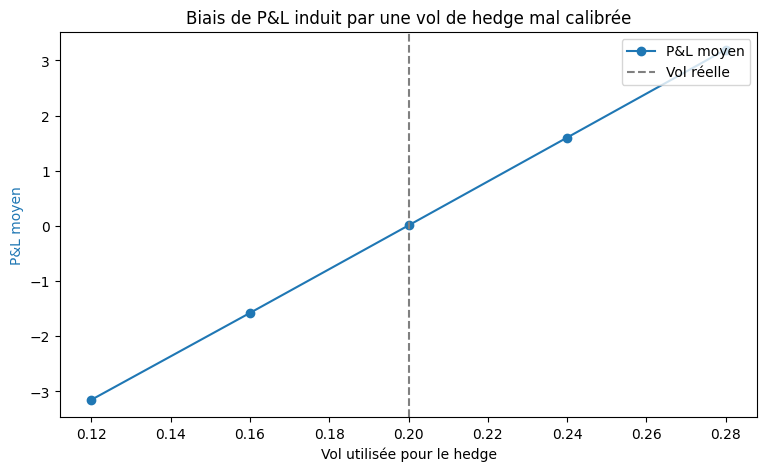

In [9]:
fig, ax1 = plt.subplots()
ax1.plot(hedge_sigmas, mean_pnls, marker='o', color='tab:blue', label='P&L moyen')
ax1.axvline(real_sigma, color='grey', ls='--', label='Vol réelle')
ax1.set_xlabel("Vol utilisée pour le hedge")
ax1.set_ylabel("P&L moyen", color='tab:blue')
ax1.legend(loc='upper right')
plt.title("Biais de P&L induit par une vol de hedge mal calibrée")
plt.show()


## 6. Conclusion

- Le P&L de couverture discrète converge vers 0 (en écart-type) quand la fréquence de
  rebalancement augmente — illustration numérique directe de l'argument de réplication
  continue de Black-Scholes, qui généralise la réplication pas-à-pas du modèle binomial
  (Shreve, Ch.1).
- Une vol de hedge **sous-estimée** tend à produire un biais de P&L différent d'une vol
  **surestimée** : sous-couvrir expose à un gamma non couvert, sur-couvrir coûte en
  transaction/portage. C'est un point clé en **validation de modèle** : un modèle de pricing
  peut être juste "en moyenne" tout en induisant un risque de couverture mal maîtrisé.

### Pistes d'extension
- Coûts de transaction (impact sur la fréquence optimale de rebalancement)
- Hedging en Gamma + Delta (portefeuille à 2 instruments)
- Comparaison avec couverture par réseau de neurones (deep hedging)

## Q&A entretien (rapide)
**Q : Pourquoi le P&L de couverture n'est-il jamais exactement nul en pratique ?**
R : Rebalancement discret (vs continu en théorie), coûts de transaction, et erreur de
calibration de la vol utilisée pour le delta.

**Q : Que mesure le Gamma et pourquoi est-il critique pour un desk de vol ?**
R : La sensibilité du Delta au sous-jacent — un Gamma élevé signifie que le hedge doit être
réajusté plus souvent, donc plus de risque de couverture discrète et plus de coûts.

**Q : Lien avec le modèle binomial de Shreve ?**
R : La réplication continue de Black-Scholes est la limite du portefeuille de réplication
binomial quand le nombre de pas tend vers l'infini ; ce notebook rend cette convergence
visible numériquement.
